In [7]:
import json
import pandas as pd
import numpy as np

with open("iris.data", "r") as f:
    data = pd.read_csv(f, header=0)

df = pd.DataFrame(data)

print(df.head())

print(df.shape)
print(df.dtypes)
# print(df["click"].value_counts())
# print(df["click"].value_counts(normalize=True))


    f1   f2   f3   f4        label
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
(150, 5)
f1       float64
f2       float64
f3       float64
f4       float64
label        str
dtype: object


In [8]:
df.describe()

,f1,f2,f3,f4
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
print (df.isna().sum())

f1       0
f2       0
f3       0
f4       0
label    0
dtype: int64


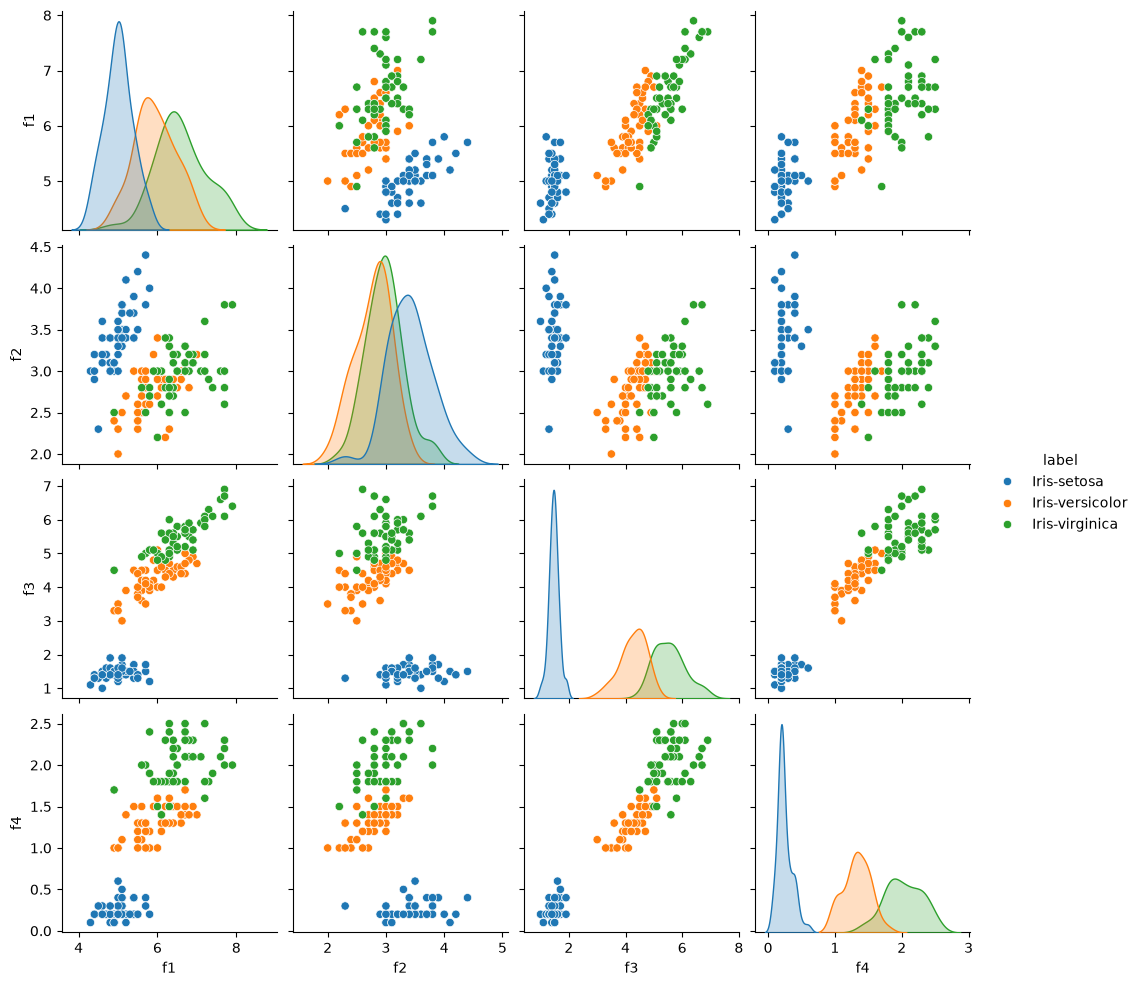

In [10]:
# import matplotlib.pyplot as plt
# plt.plot(df.click)
import seaborn as sns


sns.pairplot(df, hue="label")

In [34]:
a = np.zeros([1, 2])
b = np.ones([1, 2])
# a, b
# np.dot(a,b.T)
# np.dot(a.T,b)

df.columns = df.columns.str.strip()


def dist(a, b):
    return np.linalg.norm(a - b)


def avg_within_cluster_distance(points, clusters):
    result = []
    for cluster in clusters:
        if len(cluster) <= 1:
            result.append(0.0)
            continue

        dists = []
        for i in range(len(cluster)):
            for j in range(i + 1, len(cluster)):
                dists.append(dist(points[cluster[i]], points[cluster[j]]))

        result.append(np.mean(dists))

    return result


def update_cent(clusters, points):
    centroids = []
    for i, c in enumerate(clusters):
        centroids.append(np.mean(points[c], axis=0))

    return centroids


def k_means(points, k, max_iter):
    centroids_ind = np.random.randint(0, len(points), k)
    centroids = points[centroids_ind]

    while max_iter > 0:
        max_iter -= 1
        points_to_centroids = [[] for _ in range(k)]

        for i, p in enumerate(points):
            min_dist = float("+inf")
            min_ind = 0
            for j, c in enumerate(centroids):
                d = dist(p, c)
                if d < min_dist:
                    min_dist = d
                    min_ind = j
            points_to_centroids[min_ind].append(i)

        objective = sum(np.sum((points[cluster] - np.mean(points[cluster], axis=0)) ** 2) for cluster in points_to_centroids if len(cluster) > 0)
        print(f'iteration {max_iter}: objective = {objective}')
        centroids = update_cent(points_to_centroids, points)

    return points_to_centroids


# print(dist(a,b))
res = k_means(df.drop(columns=["label"]).to_numpy(), 3, 20)
print(res)

iteration 19: objective = 147.80326945105296
iteration 18: objective = 145.3439366334874
iteration 17: objective = 145.2793220364604
iteration 16: objective = 145.2793220364604
iteration 15: objective = 145.2793220364604
iteration 14: objective = 145.2793220364604
iteration 13: objective = 145.2793220364604
iteration 12: objective = 145.2793220364604
iteration 11: objective = 145.2793220364604
iteration 10: objective = 145.2793220364604
iteration 9: objective = 145.2793220364604
iteration 8: objective = 145.2793220364604
iteration 7: objective = 145.2793220364604
iteration 6: objective = 145.2793220364604
iteration 5: objective = 145.2793220364604
iteration 4: objective = 145.2793220364604
iteration 3: objective = 145.2793220364604
iteration 2: objective = 145.2793220364604
iteration 1: objective = 145.2793220364604
iteration 0: objective = 145.2793220364604
[[0, 4, 5, 7, 10, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 26, 27, 28, 31, 32, 33, 36, 39, 40, 43, 44, 46, 48, 57, 93, 98], [50, 5

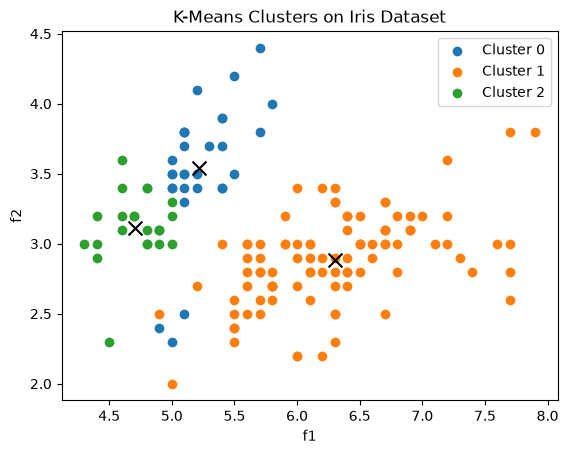

In [35]:
# Final cluster visualization
X = df.drop(columns=['label']).to_numpy()

# Use the same current clustering result from the last run
clusters = res

# Build cluster labels for each point
cluster_labels = np.empty(len(X), dtype=int)
for c_id, cluster in enumerate(clusters):
    cluster_labels[cluster] = c_id

plt = None
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('matplotlib is not installed')
    raise

# Plot first two feature dimensions
for c_id in range(len(clusters)):
    idx = np.array(clusters[c_id])
    plt.scatter(X[idx, 0], X[idx, 1], label=f'Cluster {c_id}')

# show centroids
centroids = [np.mean(X[cluster], axis=0) for cluster in clusters]
for c_id, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], s=100, marker='x', color='black')

plt.title('K-Means Clusters on Iris Dataset')
plt.xlabel('f1')
plt.ylabel('f2')
plt.legend()
plt.show()
